# Análise Exploratória dos Dados

O dataser possui 645 municípios e 80 variáveis, misturando:

- Dados geográficos (latitude, longitude)
- Infraestrutura de saúde (hospitais, clínicas, consultórios)
- Indicadores populacionais
- Procedimentos do SUS
- Receita anual
- Um índice (ids)

##### Primeiro faremos os imports e configurações necessárias para trabalhar:

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# Configurações visuais
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Tamanho padrão dos gráficos
plt.rcParams["figure.figsize"] = (10, 6)

##### Carregando os dados e ajuste na coluna de latitude e longitude

In [3]:
sp = gpd.read_file(ROOT / "SP_Municipios_2025.shp")
df = pd.read_csv(ROOT / "main_dataframe.csv")

df["latitude"] = (df["latitude"].astype(str).str.replace(",", ".").astype(float))
df["longitude"] = (df["longitude"].astype(str).str.replace(",", ".").astype(float))

print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
df.head()

DataSourceError: C:\Users\Hiago\Documents\GitHub\ProjetoIntegrador-I\SP_Municipios_2025.shp: No such file or directory

##### Funções de Plotagem

In [ ]:
# Histograma
def plot_histogram(dataframe, coluna, bins=30):

    plt.figure(figsize=(8,4))
    sns.histplot(dataframe[coluna], bins=bins, kde=True)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.show()

# Boxplot
def plot_boxplot(dataframe, coluna):

    plt.figure(figsize=(9,5))
    sns.boxplot(x=dataframe[coluna])
    plt.title(f"Boxplot - {coluna}")
    plt.show()

# Scatter
def plot_scatter(dataframe, coluna1, coluna2):
    plt.figure(figsize=(7,5))
    plt.scatter(data=df, x=coluna1, y=coluna2, s=10)
    plt.title(f"{coluna1} x {coluna2}")
    plt.show()
    
# Correlação
def plot_correlation(dataframe, tamanho=(14,10)):

    plt.figure(figsize=tamanho)
    corr = dataframe.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Matriz de Correlação")
    plt.show()

# Top Municípios
def plot_top_municipios(dataframe, coluna, top_n=15):

    top = (dataframe.sort_values(coluna, ascending=False).head(top_n))

    plt.figure(figsize=(12,6))
    sns.barplot(data=top, x=coluna, y="municipio")
    plt.title(f"Top {top_n} municípios - {coluna}")
    plt.show()

##### Visão Geral do Dataset

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 80 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   municipio                                                                          645 non-null    str    
 1   latitude                                                                           645 non-null    float64
 2   longitude                                                                          645 non-null    float64
 3   hospital_estadual                                                                  645 non-null    int64  
 4   hospital_federal                                                                   645 non-null    int64  
 5   hospital_municipal                                                                 645 non-null    int64  
 6   hospi

# Distribuição das Variáveis

### Municípios

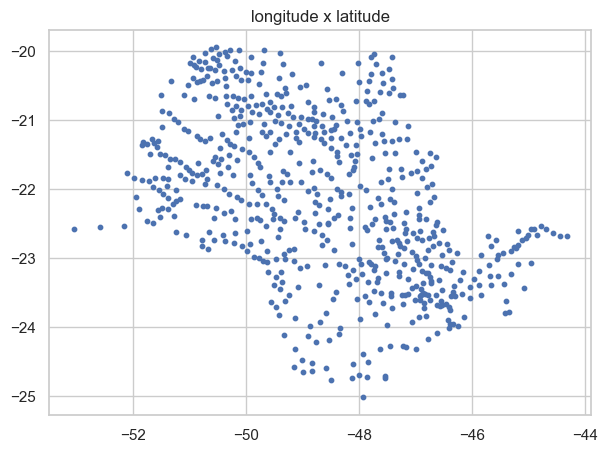

In [ ]:
plot_scatter(df, 'longitude', 'latitude')

### População

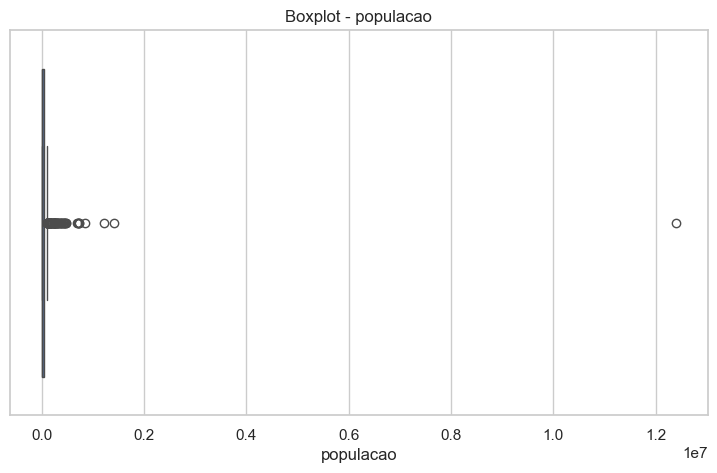

In [ ]:
plot_boxplot(df, "populacao")

### Receita

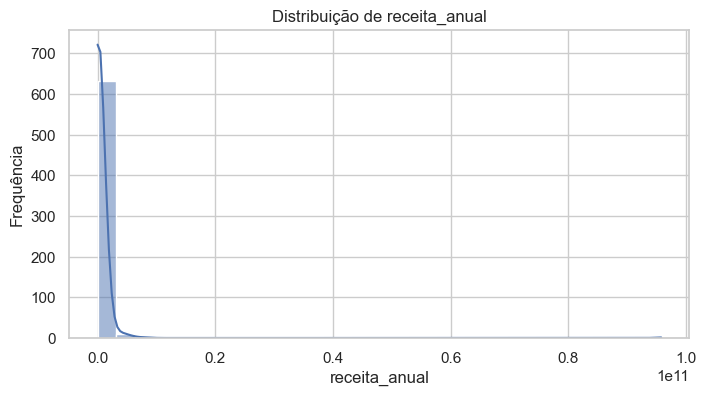

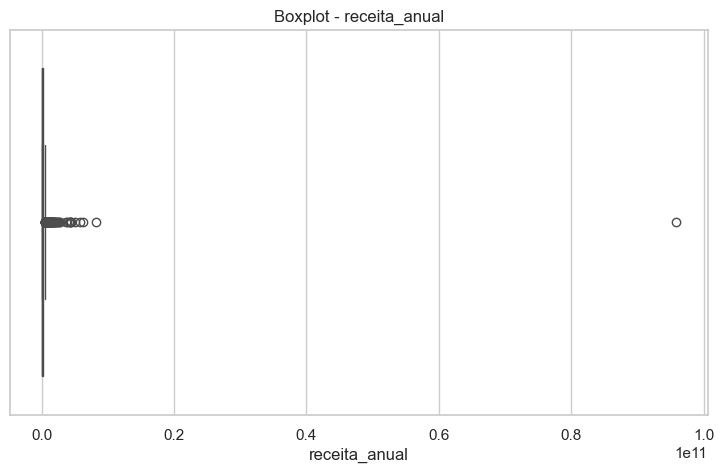

In [ ]:
plot_histogram(df, "receita_anual")
plot_boxplot(df, "receita_anual")

### IDS

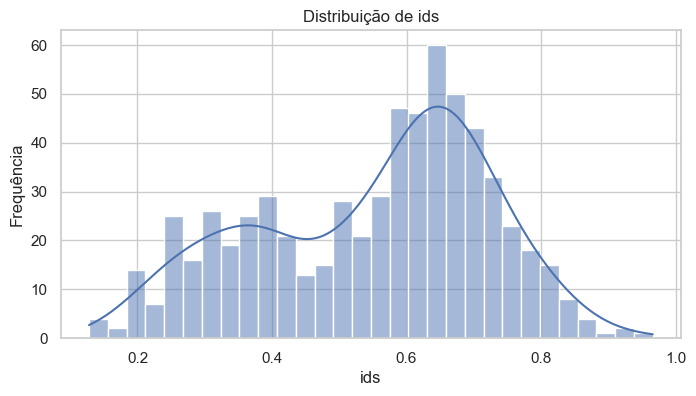

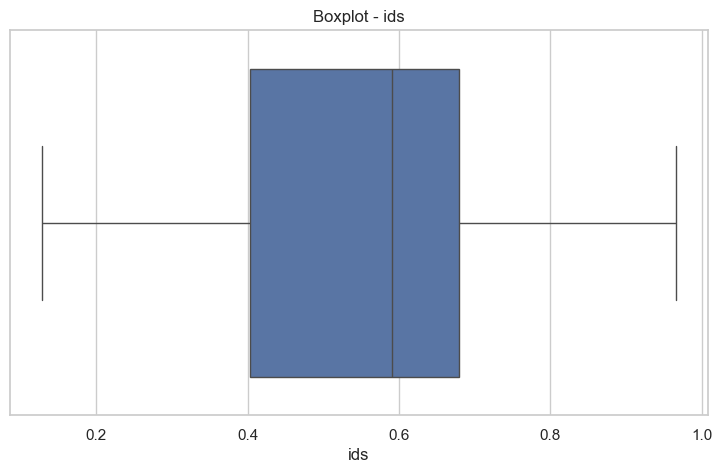

In [ ]:
plot_histogram(df, "ids")
plot_boxplot(df, "ids")

### Correlação de Variáveis

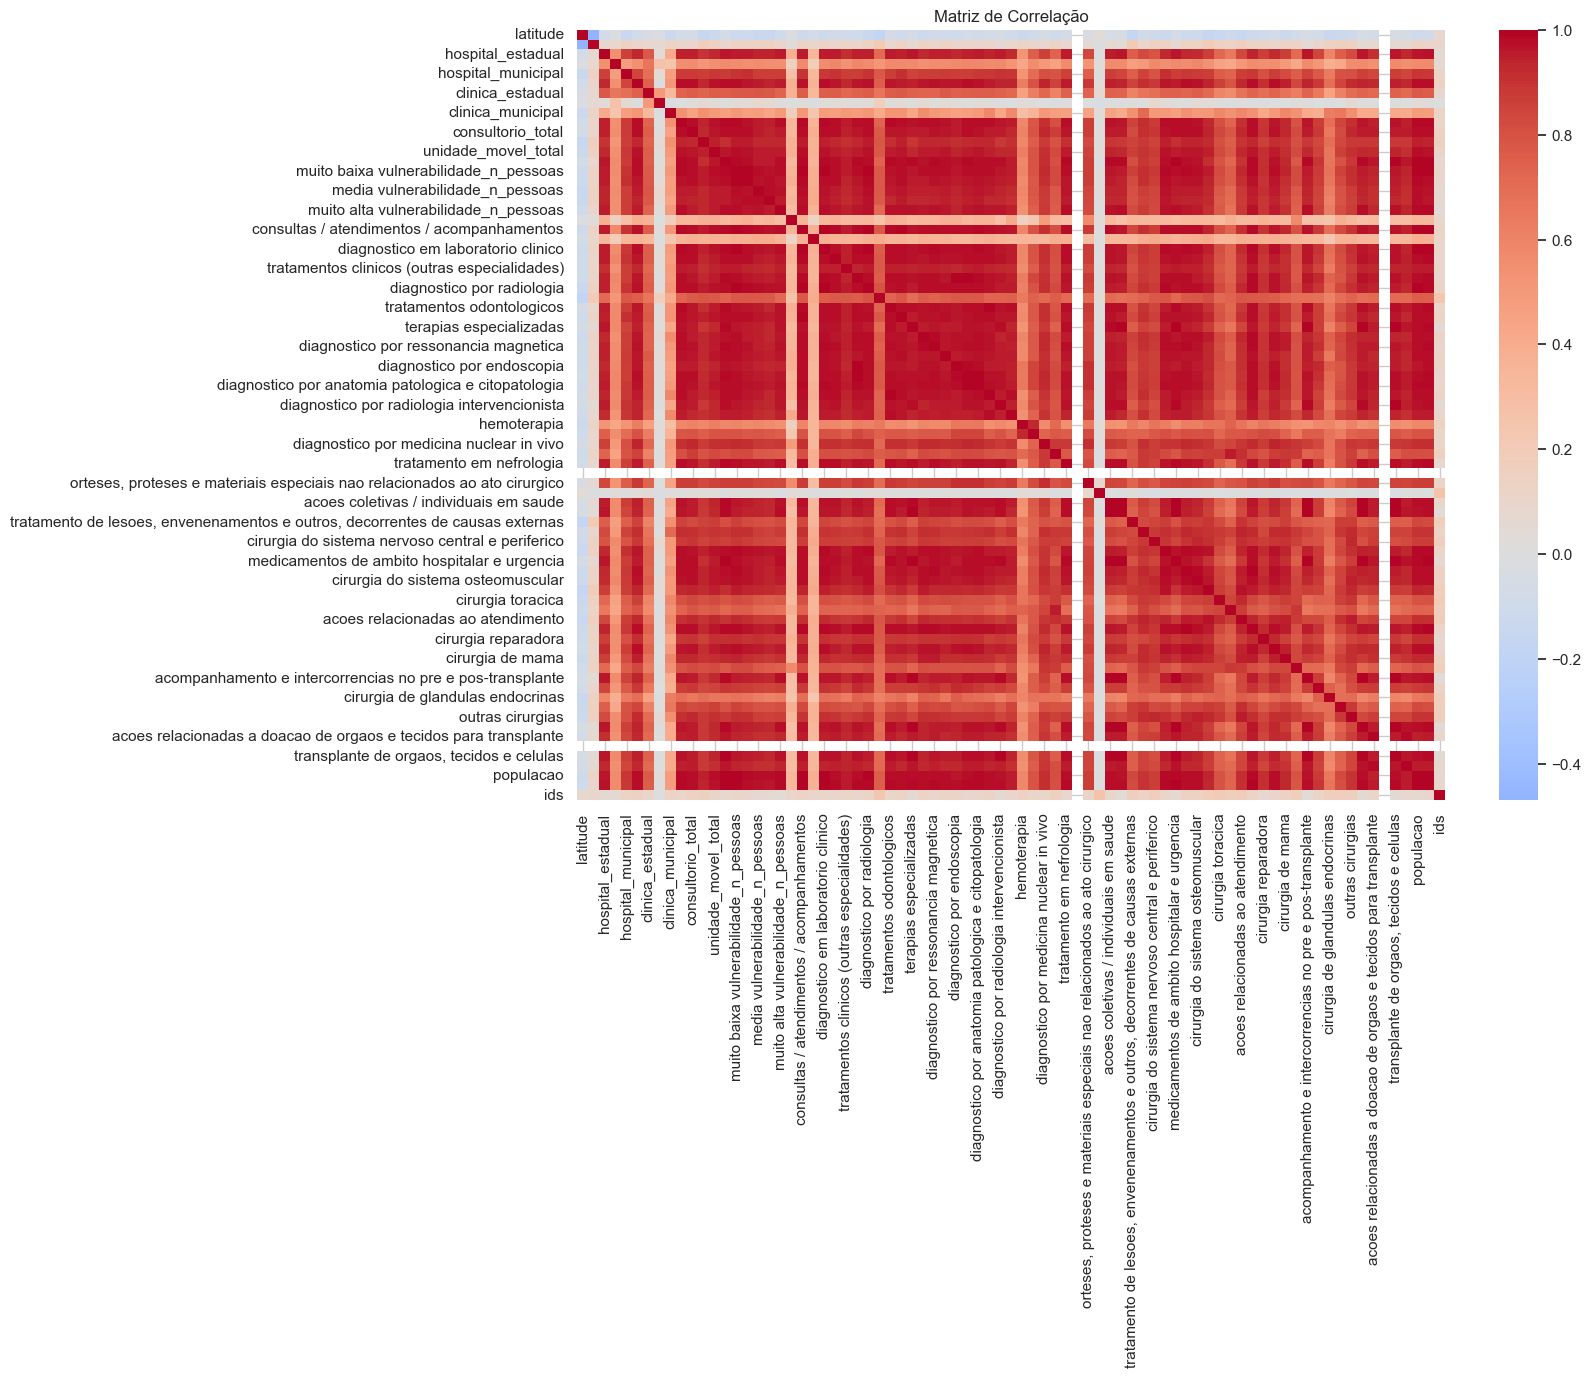

In [ ]:
plot_correlation(df)

##### Correlação com o IDS

In [ ]:
corr_ids = (df.corr(numeric_only=True)["ids"].sort_values(ascending=False))
corr_ids.head(20)

ids                                                                              1.000000
autorizacao / regulacao                                                          0.263895
fisioterapia                                                                     0.242488
cirurgia toracica                                                                0.201242
cirurgia obstetrica                                                              0.182281
acoes relacionadas ao atendimento                                                0.175415
orteses, proteses e materiais especiais relacionados ao ato cirurgico            0.172037
outras cirurgias                                                                 0.168015
cirurgia em oncologia                                                            0.166692
cirurgia de glandulas endocrinas                                                 0.164805
tratamento de lesoes, envenenamentos e outros, decorrentes de causas externas    0.163811
cirurgia e

In [ ]:
corr_ids.tail(20)

cirurgia reparadora                                                                  0.085247
populacao                                                                            0.083133
avaliacao de morte encefalica                                                        0.081582
tratamento em nefrologia                                                             0.078736
baixissima vulnerabilidade_n_pessoas                                                 0.078093
media vulnerabilidade_n_pessoas                                                      0.069237
medicamentos de ambito hospitalar e urgencia                                         0.066718
alta vulnerabilidade_n_pessoas                                                       0.065899
terapias especializadas                                                              0.063201
hospital_federal                                                                     0.062580
diagnostico por radiologia intervencionista                 

##### População Vs Receita

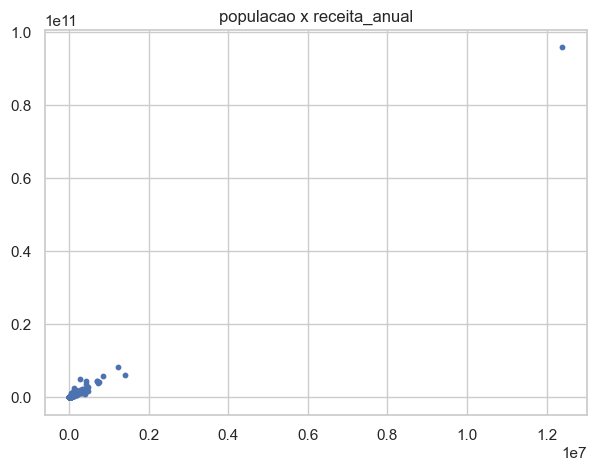

In [ ]:
plot_scatter(df, "populacao", "receita_anual")

### Municipios com maior receita

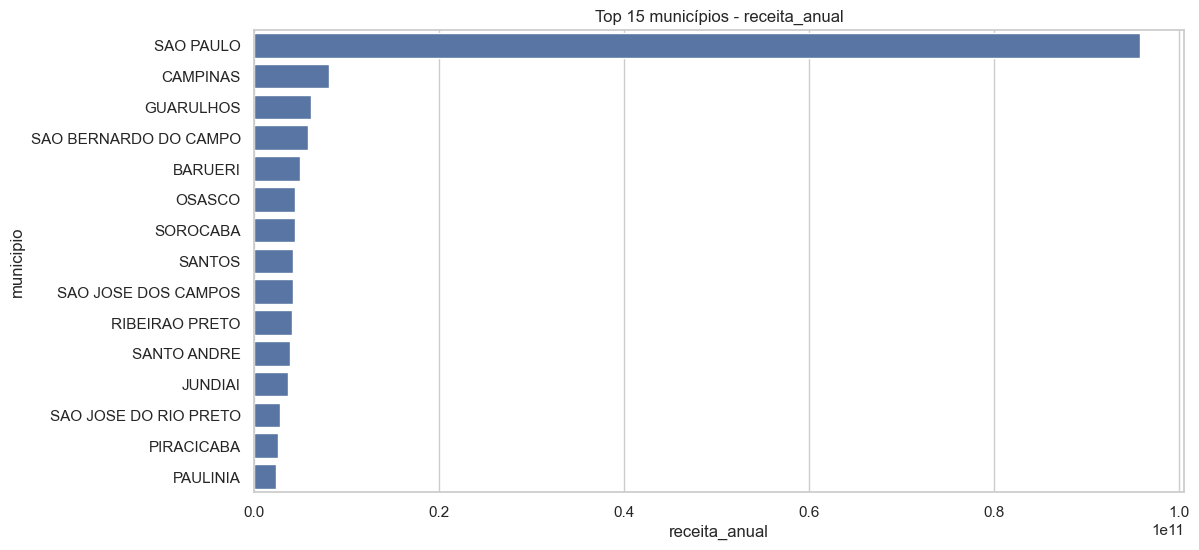

In [ ]:
plot_top_municipios(df, "receita_anual")

### Municípios com maior IDS

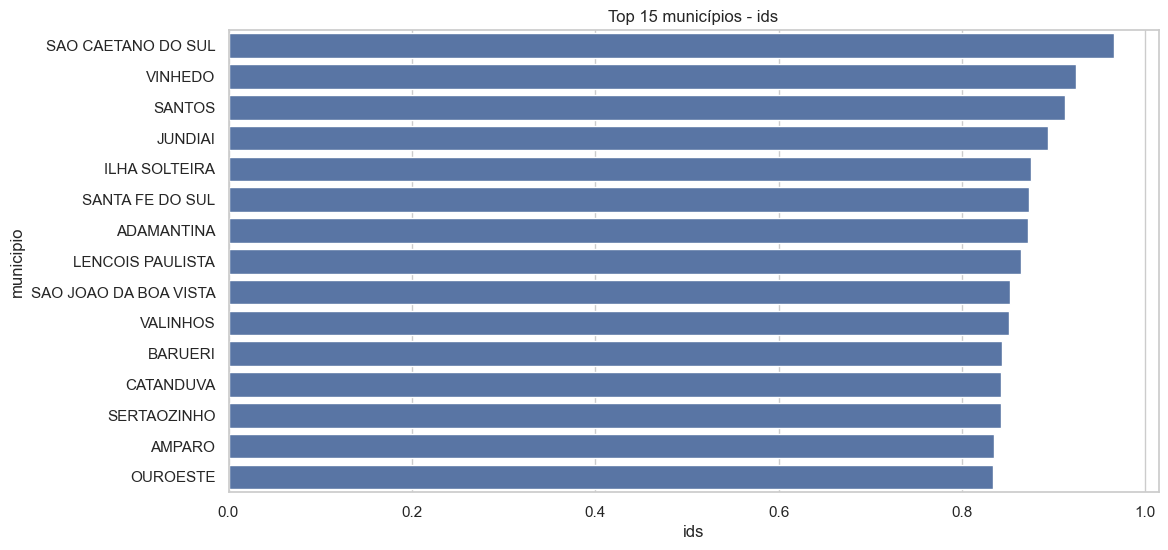

In [ ]:
plot_top_municipios(df, "ids")

### Top municípios com mais atendimentos

In [ ]:
if 'consultas / atendimentos / acompanhamentos' in df.columns:
    top_municipios = df.sort_values(by='consultas / atendimentos / acompanhamentos', ascending=False)
    print(top_municipios[['municipio', 'consultas / atendimentos / acompanhamentos']].head(10))


                 municipio  consultas / atendimentos / acompanhamentos
562              SAO PAULO                                     6666261
544  SAO BERNARDO DO CAMPO                                      653524
557    SAO JOSE DOS CAMPOS                                      504837
581               SOROCABA                                      481781
212              GUARULHOS                                      467320
64                 BARUERI                                      466404
387                 OSASCO                                      461787
487         RIBEIRAO PRETO                                      420512
556  SAO JOSE DO RIO PRETO                                      402557
534            SANTO ANDRE                                      394077


### Top municípios com mais hospitais

In [ ]:
df['total_hospitais'] = (df['hospital_estadual'] + df['hospital_federal'] + df['hospital_municipal'] + df['hospital_particular'])
top_hospitais = df.sort_values(by='total_hospitais', ascending=False)

print(top_hospitais[['municipio', 'total_hospitais']].head(10))

                 municipio  total_hospitais
562              SAO PAULO              271
108               CAMPINAS               37
557    SAO JOSE DOS CAMPOS               26
542                 SANTOS               26
544  SAO BERNARDO DO CAMPO               25
556  SAO JOSE DO RIO PRETO               24
487         RIBEIRAO PRETO               24
581               SOROCABA               21
212              GUARULHOS               18
534            SANTO ANDRE               16


### Top municípios com mais clínicas

In [ ]:
df['total_clinicas'] = (df['clinica_estadual'] + df['clinica_federal'] + df['clinica_municipal'] + df['clinica_particular'])
top_clinicas = df.sort_values(by='total_clinicas', ascending=False)

print(top_clinicas[['municipio', 'total_clinicas']].head(10))

                 municipio  total_clinicas
562              SAO PAULO            5980
544  SAO BERNARDO DO CAMPO            1141
534            SANTO ANDRE             767
487         RIBEIRAO PRETO             663
387                 OSASCO             415
557    SAO JOSE DOS CAMPOS             392
108               CAMPINAS             354
212              GUARULHOS             326
293                JUNDIAI             305
581               SOROCABA             278


### Top municípios com maior vulnerabilidade social

In [ ]:
vulnerabilidade_cols = [
    'baixissima vulnerabilidade_n_pessoas',
    'muito baixa vulnerabilidade_n_pessoas',
    'baixa vulnerabilidade_n_pessoas',
    'media vulnerabilidade_n_pessoas',
    'alta vulnerabilidade_n_pessoas',
    'muito alta vulnerabilidade_n_pessoas'
]

df['vulnerabilidade_total'] = df[vulnerabilidade_cols].sum(axis=1)
top_vulnerabilidade = df.sort_values(by='vulnerabilidade_total', ascending=False)

print(top_vulnerabilidade[['municipio', 'vulnerabilidade_total']].head(10))

                 municipio  vulnerabilidade_total
562              SAO PAULO               11341162
212              GUARULHOS                1278436
108               CAMPINAS                1129353
544  SAO BERNARDO DO CAMPO                 807131
534            SANTO ANDRE                 740195
387                 OSASCO                 723345
581               SOROCABA                 717745
487         RIBEIRAO PRETO                 691545
557    SAO JOSE DOS CAMPOS                 690903
556  SAO JOSE DO RIO PRETO                 475487


### Relação entre vulnerabilidade e atendimentos

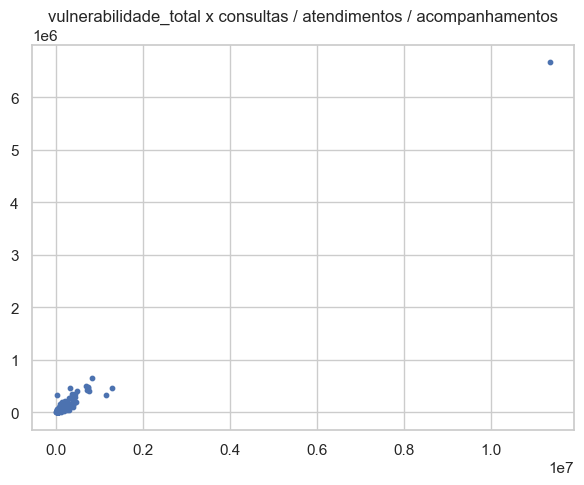

In [ ]:
plot_scatter(df, 'vulnerabilidade_total', 'consultas / atendimentos / acompanhamentos')

### Municípios que não tem hospitais

In [ ]:
sem_hospital = df[df['total_hospitais'] == 0]
print(sem_hospital['municipio'].head(20))

print(f"\nTotal: {len(sem_hospital)}")

1                     ADOLFO
3             AGUAS DA PRATA
5     AGUAS DE SANTA BARBARA
6         AGUAS DE SAO PEDRO
8                   ALAMBARI
9          ALFREDO MARCONDES
10                    ALTAIR
13                  ALUMINIO
14          ALVARES FLORENCE
16        ALVARO DE CARVALHO
17               ALVINLANDIA
20         AMERICO DE CAMPOS
22                 ANALANDIA
24                  ANGATUBA
25                   ANHEMBI
26                   ANHUMAS
27                 APARECIDA
28         APARECIDA D'OESTE
30              ARACARIGUAMA
33                   ARAMINA
Name: municipio, dtype: str

Total: 321


### Renda Per Capita

In [ ]:
df['valor_per_capita'] = (df['receita_anual'] / df['populacao'])

print(df[['municipio', 'valor_per_capita']].sort_values(by='valor_per_capita',ascending=True).head(10))

                 municipio  valor_per_capita
253                 ITAOCA        408.618881
121            CARAPICUIBA       2302.383179
494    RIO GRANDE DA SERRA       2778.738210
180  FERRAZ DE VASCONCELOS       3160.968519
264        ITAQUAQUECETUBA       3184.223567
330                   MAUA       3215.686691
186       FRANCISCO MORATO       3261.426649
185                 FRANCA       3309.784987
168             EMBU-GUACU       3403.256816
634        VARZEA PAULISTA       3570.968695


### Vulnerabilidade e Gasto Público

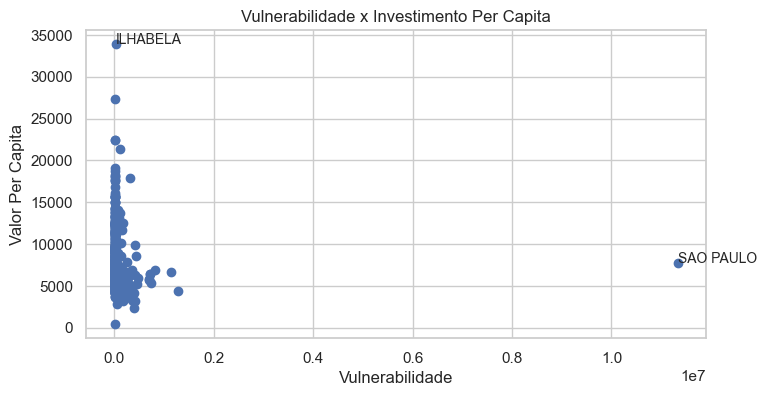

In [ ]:
top_vulneravel = df.loc[df['vulnerabilidade_total'].idxmax()]
top_valorPerCapita = df.loc[ df['valor_per_capita'].idxmax()]

plt.figure(figsize=(8,4))
plt.scatter(df['vulnerabilidade_total'], df['valor_per_capita'])
plt.annotate(top_vulneravel['municipio'], (top_vulneravel['vulnerabilidade_total'], 
                                           top_vulneravel['valor_per_capita']), fontsize=10)

plt.annotate(top_valorPerCapita['municipio'], (top_valorPerCapita['vulnerabilidade_total'], 
                                               top_valorPerCapita['valor_per_capita']), fontsize=10)

plt.xlabel('Vulnerabilidade')
plt.ylabel('Valor Per Capita')
plt.title('Vulnerabilidade x Investimento Per Capita')

plt.show()

### Mapas cloropéticos

Primeiro vamos precisar combinar o Shapefile com o nosso dataset

In [ ]:
sp["NM_MUN"] = (sp["NM_MUN"].str.upper())
df["municipio"] = (df["municipio"].str.upper())

Fazendo o merge

In [ ]:
mapa = sp.merge(df, left_on="NM_MUN", right_on="municipio", how="left")

### MAPA IDS

(np.float64(-53.557548815000004),
 np.float64(-43.713927885),
 np.float64(-25.366878000000003),
 np.float64(-19.513597599999898))

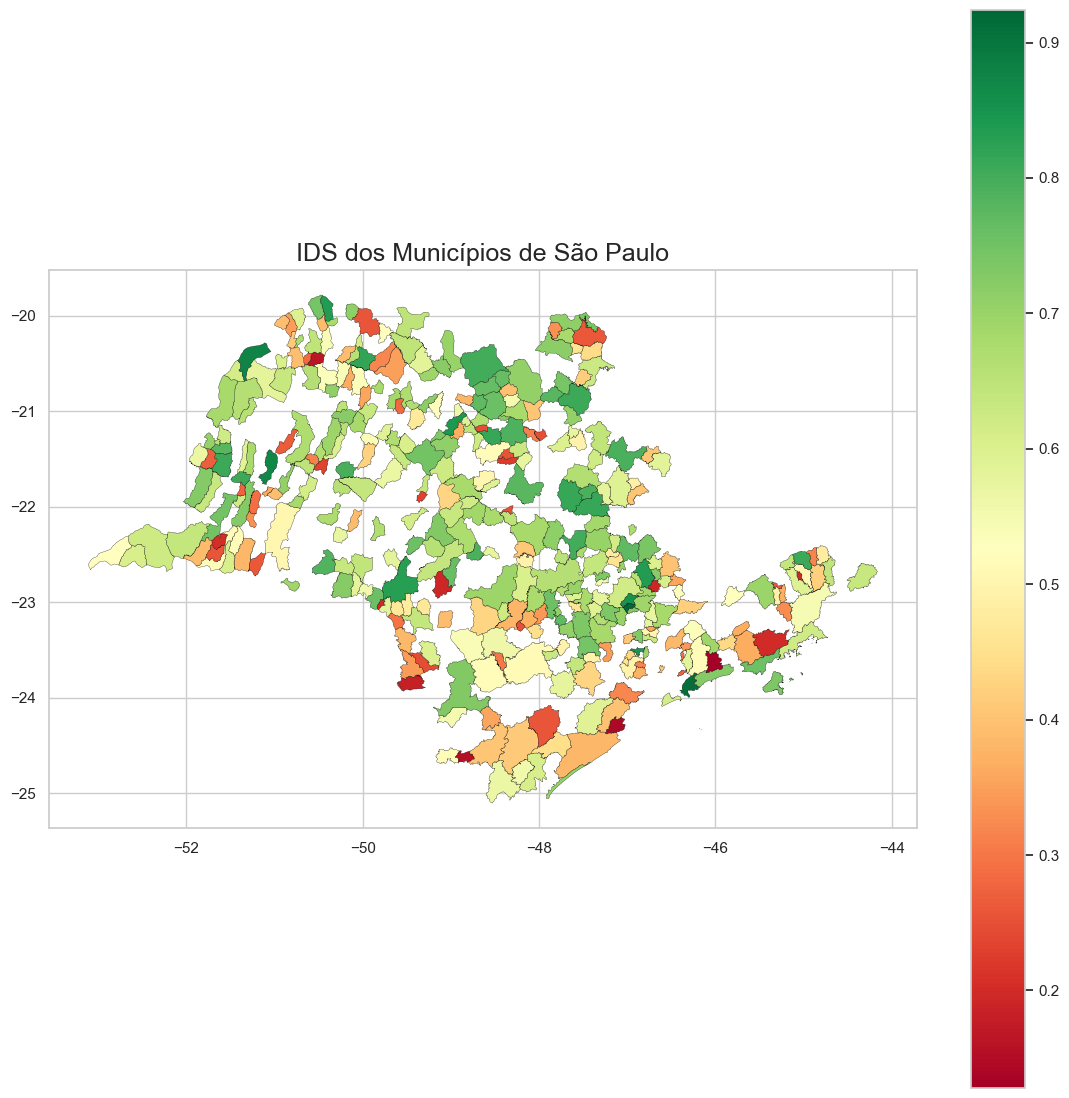

In [ ]:
fig, ax = plt.subplots(figsize=(14,14))
mapa.plot(column="ids", cmap="RdYlGn", legend=True, linewidth=0.2, edgecolor="black", ax=ax)
ax.set_title("IDS dos Municípios de São Paulo", fontsize=18)
ax.axis("on")

In [ ]:
print(len(sp))
print(len(mapa))
print(mapa["ids"].isna().sum())

645
645
274


### Receita Per Capita

<Axes: >

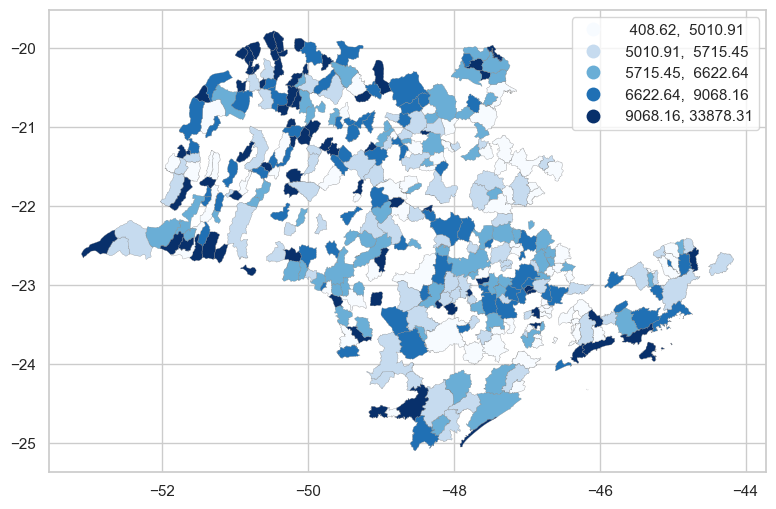

In [ ]:
mapa.plot(column="valor_per_capita", cmap="Blues", scheme="quantiles", linewidth=0.2, edgecolor="gray", k=5, legend=True)

### Hospitais por 10.000 habitantes

TypeError: Axes.annotate() missing 1 required positional argument: 'xy'

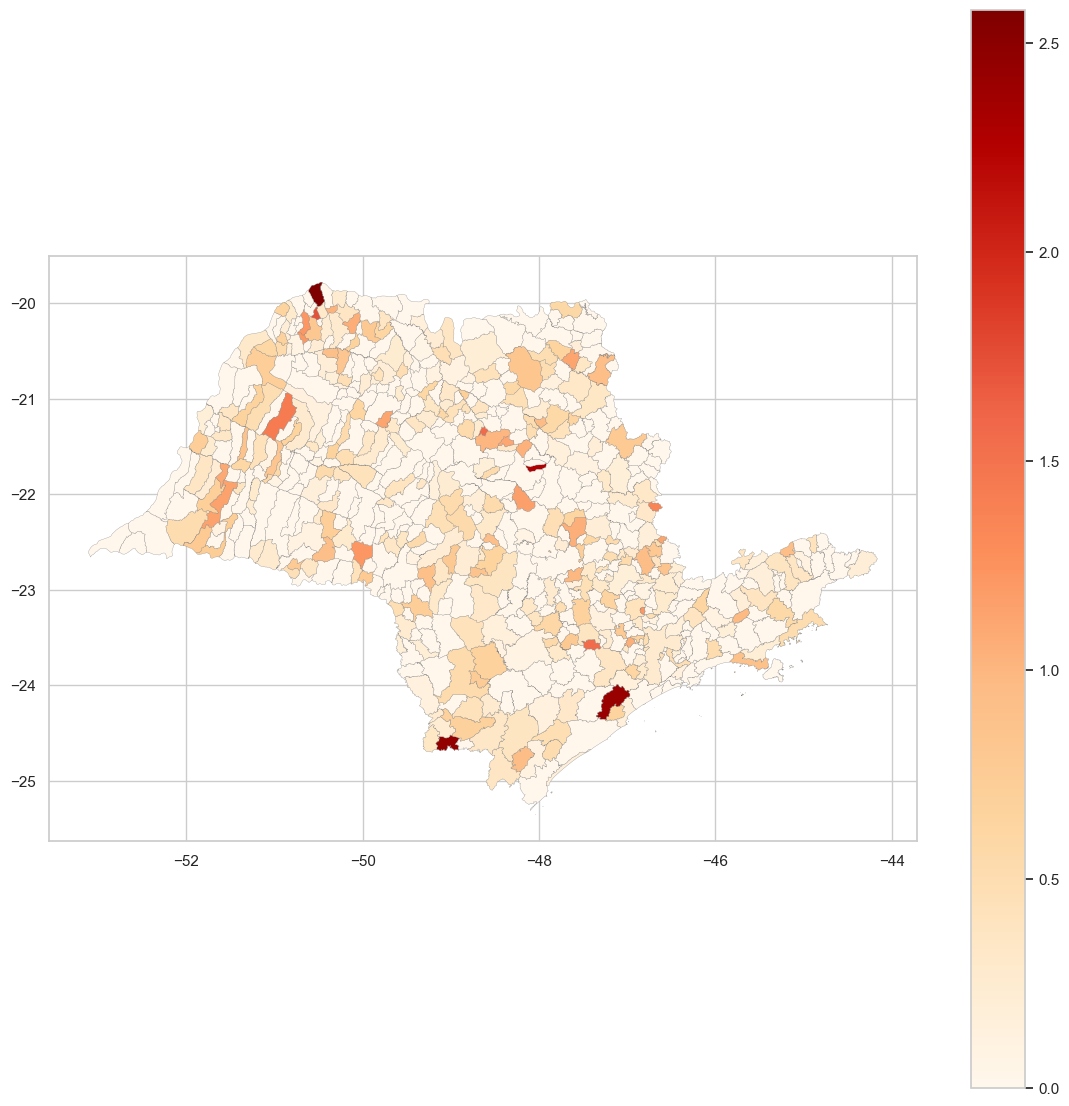

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))
mapa.plot(column=(df["total_hospitais"] / df["populacao"]) * 10000, cmap="OrRd", legend=True, linewidth=0.2, edgecolor="gray", ax=ax)

mais_hospitais = mapa.loc[(df["total_hospitais"] / df["populacao"]) * 10000]

x = mais_hospitais.geometry.centroid.x
y = mais_hospitais.geometry.centroid.y

ax.annotate(text=mais_hospitais["NM_MUN"], (x, y), fontsize=10, fontweight="bold")
ax.set_title("Hospitais por 10 mil habitantes", fontsize=18)
ax.axis("off")

plt.show()

### IDS por valor per capita

Quanto IDS o município consegue obter para cada unidade de receita disponível por habitante.

Município	IDS	Receita per capita
A	0.80	10.000
B	0.80	5.000

Resultado:

A = 0.80 / 10000 = 0.00008

B = 0.80 / 5000 = 0.00016

O município B atinge o mesmo IDS com metade da receita per capita.

(np.float64(-53.557548815000004),
 np.float64(-43.713927885),
 np.float64(-25.636917000000008),
 np.float64(-19.500738599999895))

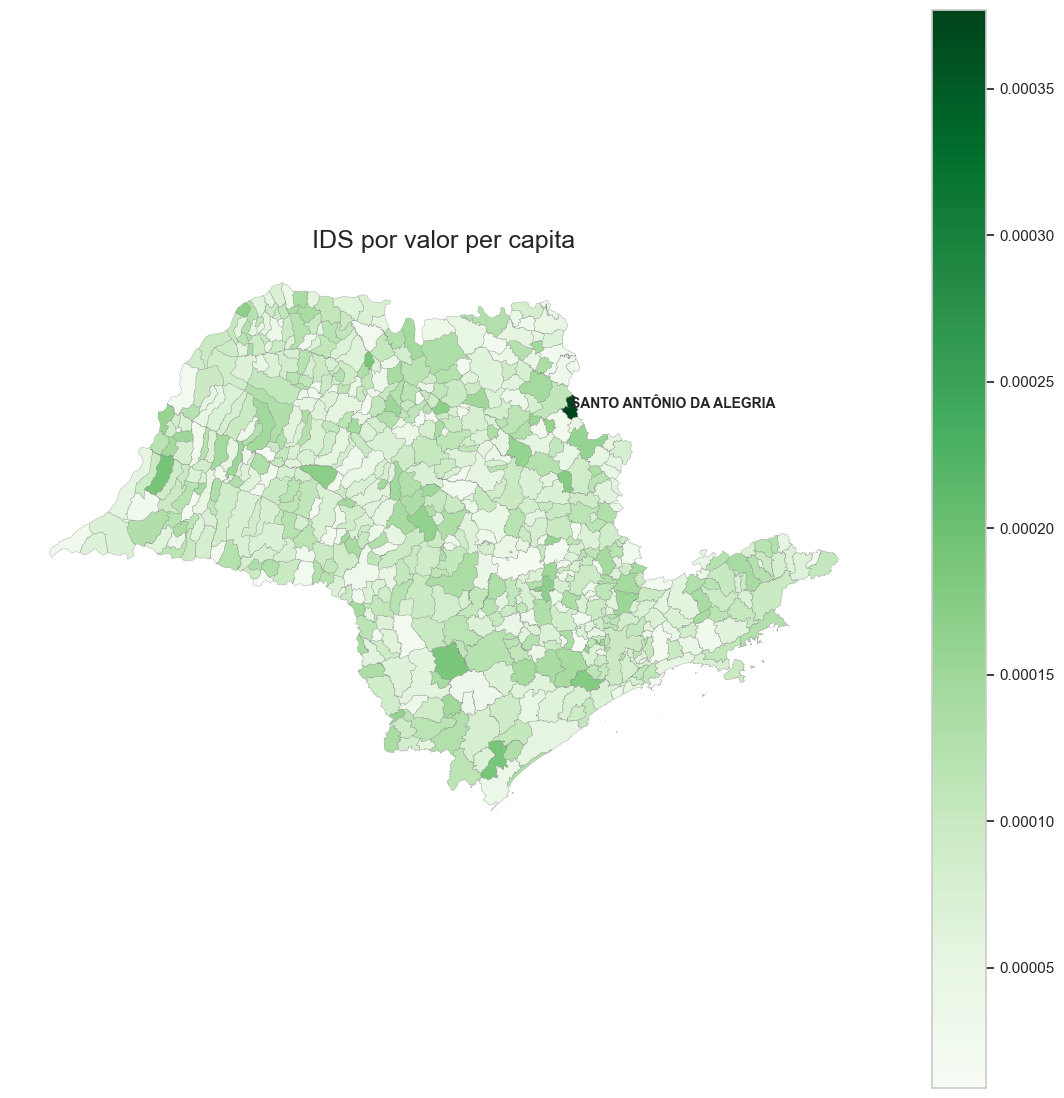

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))
mapa.plot(column=(df["ids"] / df["valor_per_capita"]), cmap="Greens", legend=True, linewidth=0.2, edgecolor="gray", ax=ax)
maior_ids = mapa.loc[(df["ids"] / df["valor_per_capita"]).idxmax()]

x = maior_ids.geometry.centroid.x
y = maior_ids.geometry.centroid.y

ax.annotate(text=maior_ids["NM_MUN"], xy=(x, y), fontsize=10, fontweight="bold")
ax.set_title("IDS por valor per capita", fontsize=18)
ax.axis("off")

IDS vs Infraestrutura

Quão eficiente é um município em transformar sua infraestrutura de saúde em resultados (IDS)?

Maior eficiência na gestão;
Melhor distribuição dos recursos;
Ou simplesmente que a métrica de infraestrutura não captura toda a realidade.

(np.float64(-53.557548815000004),
 np.float64(-43.713927885),
 np.float64(-25.636917000000008),
 np.float64(-19.500738599999895))

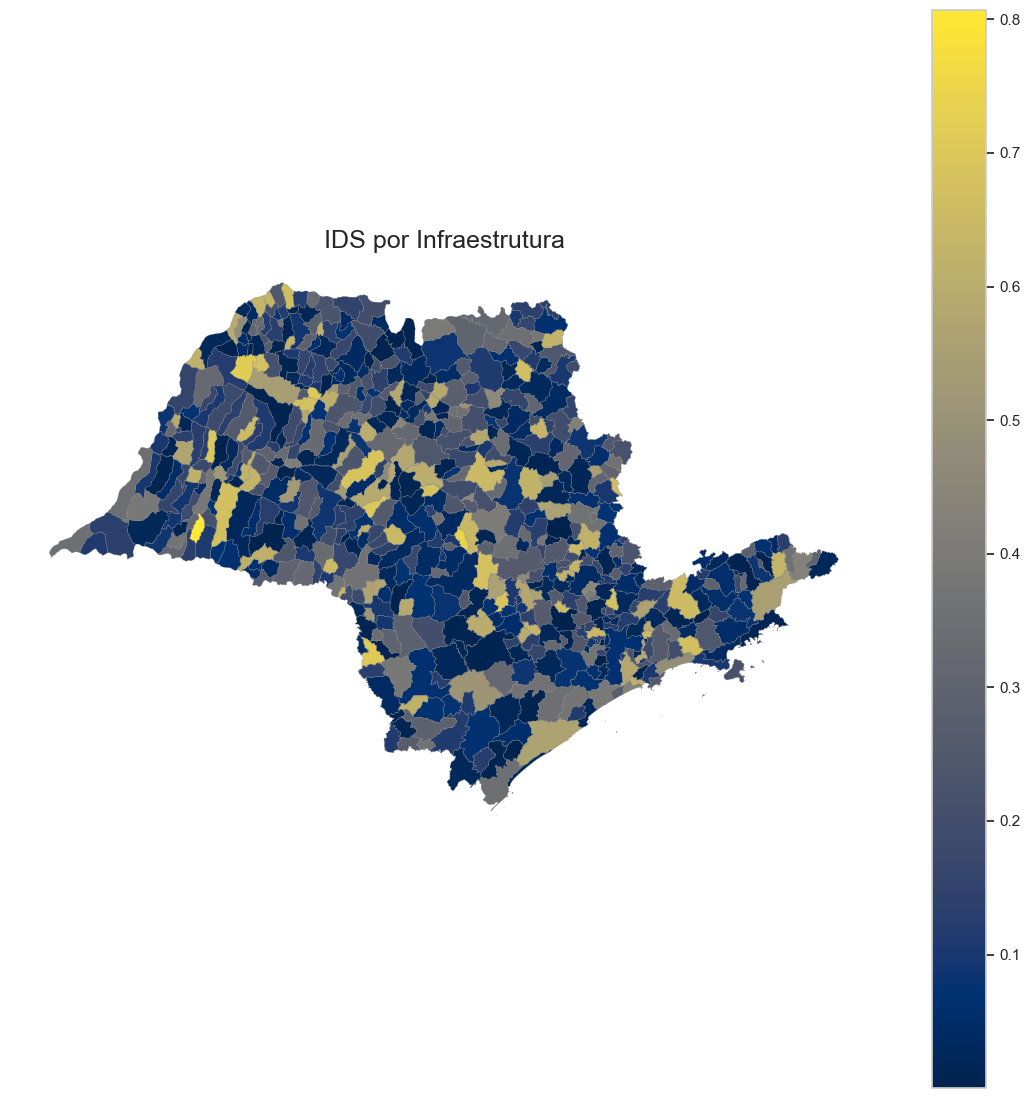

In [ ]:
fig, ax = plt.subplots(figsize=(14, 14))
mapa.plot(column=(df["ids"] / (df["total_hospitais"] + df["total_clinicas"] + 1)), cmap="cividis", legend=True, linewidth=0.2, edgecolor="gray", ax=ax)
ax.set_title("IDS por Infraestrutura", fontsize=18)
ax.axis("off")